<h1 style="text-align: center;">Sales Forecasting LSTM</h1>

The goal of this project is to forecast product sales using time series forecasting techniques.

Accurate sales forecasting helps businesses optimize inventory management, reduce waste, and improve operational efficiency. In this project, we use Long Short-Term Memory (LSTM) networks to predict future sales based on historical demand patterns.

Import libraries and load dataset

In [19]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [20]:
#load dataset
df = pd.read_csv("sales.csv")

In [21]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


EDA - Exploratory Data Analysis

In [22]:
df.shape

(4565000, 8)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [24]:
#convert date column to datetime

df["date"] = pd.to_datetime(df["date"])
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [25]:
#check number of stores and items
print("Unique stores:", df["store_id"].nunique())
print("Unique items:", df["item_id"].nunique())

Unique stores: 50
Unique items: 50


In [26]:
#filter one store and one item
data = df[(df["store_id"] == "store_1") & (df["item_id"] == "item_1")]

print(data.shape)
data.head()

(1826, 8)


,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [27]:
#Sort + index
data = data.sort_values("date")
data.set_index("date", inplace=True)

In [29]:
#keep only target column

data = data[["sales"]]
data.head()

,sales
date,
2019-01-01,41
2019-01-02,53
2019-01-03,39
2019-01-04,35
2019-01-05,51


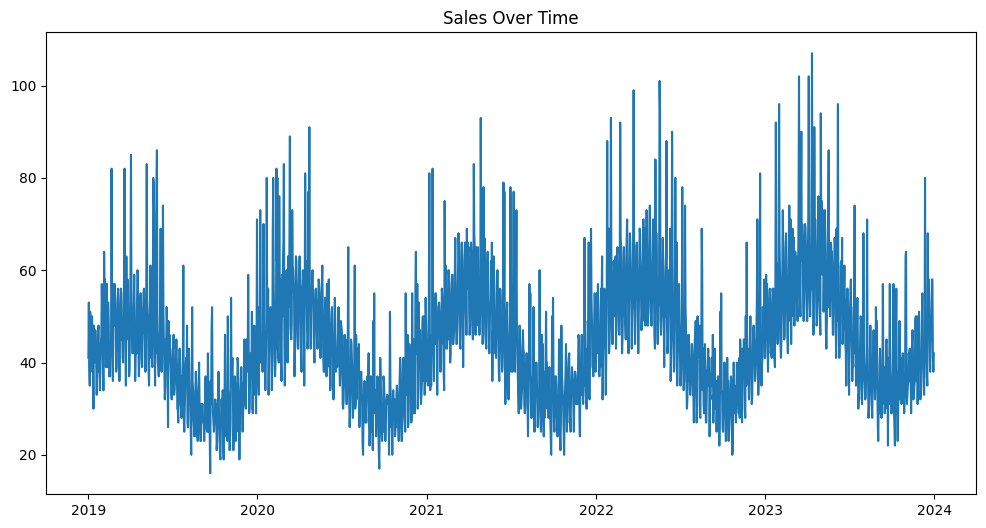

In [30]:
#Plot
plt.figure(figsize=(12,6))
plt.plot(data["sales"])
plt.title("Sales Over Time")
plt.show()

Preprocessing

In [31]:
#scale target values using MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

scaled_data[:5]

array([[0.27472527],
       [0.40659341],
       [0.25274725],
       [0.20879121],
       [0.38461538]])

In [32]:
#create sequences for LSTM
import numpy as np

def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

SEQ_LENGTH = 30

X, y = create_sequences(scaled_data, SEQ_LENGTH)

print(X.shape, y.shape)

(1796, 30, 1) (1796, 1)


In [33]:
#train test split

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(1436, 30, 1) (360, 30, 1)
(1436, 1) (360, 1)


Modeling

In [34]:
#Build LSTM model

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(optimizer="adam", loss="mean_squared_error")

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
#Train model

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0188 - val_loss: 0.0161
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0128 - val_loss: 0.0154
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0129 - val_loss: 0.0154
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - val_loss: 0.0155
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0127 - val_loss: 0.0164
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0124 - val_loss: 0.0157
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0123 - val_loss: 0.0152
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0126 - val_loss: 0.0156
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0127 - val_loss: 0.0182
Epoch 10/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0124 - val_loss: 0.0151


In [36]:
#generate predictions

train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [37]:
#Inverse transform predictions and targets

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

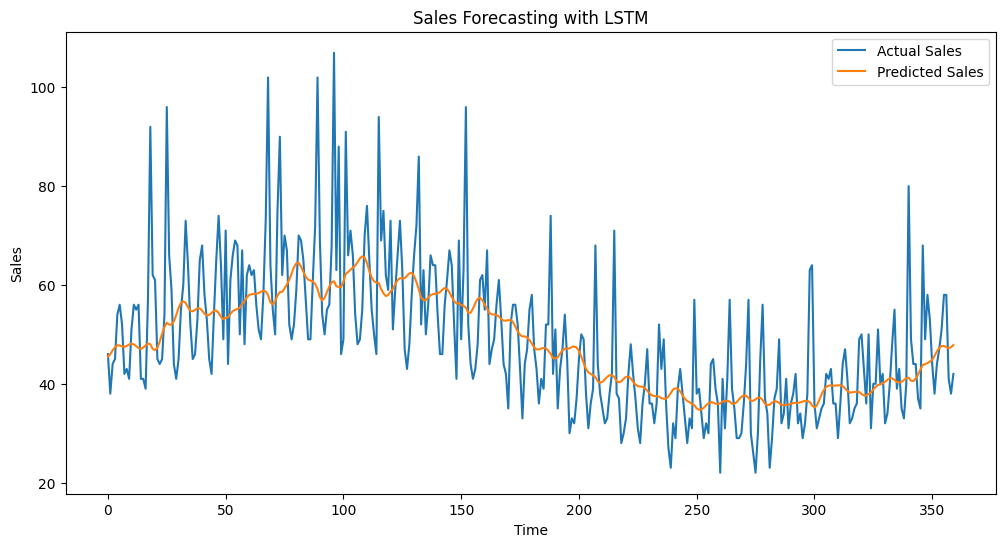

In [38]:
#Plot actual vs predicted sales

plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual Sales")
plt.plot(test_predict, label="Predicted Sales")
plt.title("Sales Forecasting with LSTM")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

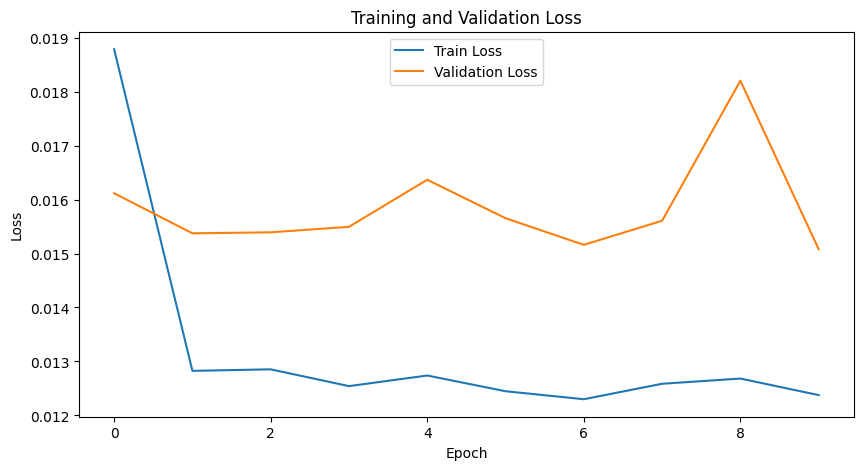

In [39]:
#Plot training and val. loss

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

Conclusion:
This project demonstrates how LSTM networks can effectively model and forecast sales using time series data.

The model successfully captured overall demand trends while smoothing noisy fluctuations commonly seen in retail sales data. The results highlight the effectiveness of sequence modeling and proper preprocessing techniques in real-world forecasting tasks.

This project shows how deep learning approaches can support data-driven decision making in business environments such as inventory planning and demand forecasting.

Saving

In [40]:
#save trained LSTM model
model.save("sales_lstm_model.keras")

In [41]:
#save fitted scaler

import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)